## Import Packages

In [1]:
# importing packages
import pyomo.environ as pyo
import numpy as np
from matplotlib import pyplot as plt
import math
import scipy.stats as stats
from scipy.optimize import fsolve, bisect, minimize
import pandas as pd
import conductivity as cd
from scipy.optimize import brute
from scipy.optimize import differential_evolution

## NaCl Data

In [2]:
# loading NaCl specific conductivity data
specific_data = pd.read_csv("./Data/NaCl.csv")
salt_conc = specific_data["NaCl conc"]
cond_exp = specific_data["NaCl cond cal"]

# number of data points
ndata = len(cond_exp)

In [3]:
# loading CaCl2 specific conductivity data
specific_data_Ca = pd.read_csv("./Data/CaCl2.csv")
salt_conc_Ca = specific_data_Ca["CaCl2_conc"]
cond_exp_Ca = specific_data_Ca["CaCl2_cond_cal"]

# number of data points
ndata_Ca = len(cond_exp_Ca)

## Constants

In [4]:
# temperature
temp = 298.15

# diffusion coefficients at infinite dilution
Diff_Na = 1.334 * 10**(-9)
Diff_Cl = 2.032 * 10**(-9)
Diff_Ca = 0.792 * 10**(-9)
Diff_La = 0.619 * 10**(-9)
diffusion_coeff = [Diff_Na, Diff_Cl] 
diffusion_coeff_Ca = [Diff_Ca, Diff_Cl] 

# valencies
z_Na = 1
z_Cl = -1
z_Ca = 2
z_La = 3
valency = [z_Na, z_Cl]
valency_Ca = [z_Ca, z_Cl]

# measuring voltage and probe distance
voltage = 25 * 10**(-3)
distance = 9 * 10**(-6)

# solvent viscosity
eta_msa = 0.89 * 10**(-3)

# electric field
E_field = voltage/distance

# relative permittivity
epsilon = 78.4

In [5]:
def msa_transport(valency, diameters, diff_coeff, T, sensor_voltage, probe_distance, eta, epsilon,
                           salt_1_conc, salt_2_conc=None, salt_3_conc=None):
    """Calculates the specific conductivity of single-salt, two-salt, and three-salt solutions

    Argument:
        valency: list of the valency of ions with cations listed before anions in decreasing order
        diameters: list of the corresponding hard sphere diameter of the ions in pm
        diff_coeff: list of the corresponding diffusion coefficient of the ions at infinite dilution in m^2/s
        T: integer or float value of the temperature in K
        sensor_voltage: integer or float value of the sensor measuring voltage in V
        probe_distance: integer or float value of the distance between the probes in m
        eta: integer or float value of the viscosity in Pa.s
        epsilon: integer or float value of the relative permittivity
        salt_1_conc = Pandas series or list of the concentration of salt 1 in mM
        salt_2_conc = Pandas series or list of the concentration of salt 2 in mM
        salt_3_conc = Pandas series or list of the concentration of salt 3 in mM

    Returns:
        all_cond_calc_con: specific conductivity of the salt solution in micro.S/cm"""

    # constants
    Avogadros_num = 6.022 * 10**23 # Avogadro's constant
    k_B = 1.381 * 10**(-23) # Boltzmann constant in J/K
    charge = 1.602 * 10**(-19) # elementary charge in C
    epsilon_0 = 8.854 * 10**(-12) # permittivity of free space in F/m

    # diameters in m
    diameters = [diameters[i] * 10**(-12) for i in range(len(diameters))]

    # electric field
    E_field = sensor_voltage/probe_distance

    # number of data points
    ndata = len(salt_1_conc)

    # number of species
    n_species = len(valency)

    # species charge
    ion_charge = [valency[i] * charge for i in range(len(valency))]

    # converting molar concentrations to number density
    if salt_2_conc is None and salt_3_conc is None:
        number_density_salt_1 = [salt_1_conc[i] * Avogadros_num for i in range(ndata)]

        # valency of cation
        valency_cation = valency[0]

        # evaluating the number density of individual species
        number_density_cat_1 = number_density_salt_1
        number_density_an = [valency_cation * number_density_salt_1[i] for i in range(ndata)]
    elif salt_2_conc is not None and salt_3_conc is None:
        number_density_salt_1 = [salt_1_conc[i] * Avogadros_num for i in range(ndata)]
        number_density_salt_2 = [salt_2_conc[i] * Avogadros_num for i in range(ndata)]

        # valency of cations
        valency_cation_1 = valency[0]
        valency_cation_2 = valency[1]

        # evaluating the number density of individual species
        number_density_cat_1 = number_density_salt_1
        number_density_cat_2 = number_density_salt_2
        number_density_an = [valency_cation_1 * number_density_salt_1[i] + valency_cation_2 * number_density_salt_2[i]
                             for i in range(ndata)]
    else:
        number_density_salt_1 = [salt_1_conc[i] * Avogadros_num for i in range(ndata)]
        number_density_salt_2 = [salt_2_conc[i] * Avogadros_num for i in range(ndata)]
        number_density_salt_3 = [salt_3_conc[i] * Avogadros_num for i in range(ndata)]

        # valency of cations
        valency_cation_1 = valency[0]
        valency_cation_2 = valency[1]
        valency_cation_3 = valency[2]

        # evaluating the number density of individual species
        number_density_cat_1 = number_density_salt_1
        number_density_cat_2 = number_density_salt_2
        number_density_cat_3 = number_density_salt_3
        number_density_an = [valency_cation_1 * number_density_salt_1[i] + valency_cation_2 * number_density_salt_2[i]
                             + valency_cation_3 * number_density_salt_3[i] for i in range(ndata)]

    # calculate the bulk conductivity of the salt solution
    all_cond_calc = np.zeros(ndata)
    for n in range(ndata): # loop through the salts concentration
        if salt_2_conc is None and salt_3_conc is None:
            # number density of species
            n_cat = number_density_cat_1[n]
            n_an = number_density_an[n]
            number_density = [n_cat, n_an]
        elif salt_2_conc is not None and salt_3_conc is None:
            # number density of species
            n_cat_1 = number_density_cat_1[n]
            n_cat_2 = number_density_cat_2[n]
            n_an = number_density_an[n]
            number_density = [n_cat_1, n_cat_2, n_an]
        else:
            # number density of species
            n_cat_1 = number_density_cat_1[n]
            n_cat_2 = number_density_cat_2[n]
            n_cat_3 = number_density_cat_3[n]
            n_an = number_density_an[n]
            number_density = [n_cat_1, n_cat_2, n_cat_3, n_an]

        # calculate the species ionic mobility (omega) and the relative ionic strength (mew)
        omega = np.zeros(n_species)
        mew = np.zeros(n_species)
        for a in range(n_species):
            omega[a] = diff_coeff[a] / (k_B * T)
            mew[a] = number_density[a] * ion_charge[a] ** 2 / sum(
                number_density[j] * ion_charge[j] ** 2 for j in range(n_species))

        # calculate the Debye length from equation (5)
        kappa = math.sqrt(
            sum(number_density[l] * ion_charge[l] ** 2 / (epsilon * epsilon_0 * k_B * T) for l in range(n_species)))

        # calculate the mean mobility from equation (7)
        omega_bar = sum(mew[j] * omega[j] for j in range(n_species))

        # calculate the transport number of all species from equation (8)
        transport_num = np.zeros(n_species)
        for j in range(n_species):
            transport_num[j] = mew[j] * omega[j] / omega_bar

        # calculate delta from equation (21)
        delta = 1 - ((math.pi / 6) * sum(number_density[k] * diameters[k] ** 3 for k in range(n_species)))

        # function that evaluates equation (18)
        def func_gamma(gamma):
            """
            Evaluates residual of equation (18)

            Arguments:
                gamma

            Returns:
                Residual of the equation
            """
            # calculating capital omega from equation (20)
            capital_omega = 1 + ((math.pi / (2 * delta)) * sum(
                number_density[k] * diameters[k] ** 3 / (1 + gamma * diameters[k]) for k in range(n_species)))

            # calculating Pn from equation (19)
            P_n = (1 / capital_omega) * sum(
                number_density[k] * diameters[k] * valency[k] / (1 + gamma * diameters[k]) for k in range(n_species))

            return (4 * epsilon_0 * gamma ** 2 - ((charge ** 2) / (epsilon * k_B * T)) *
                    sum(number_density[l] * ((valency[l] - (math.pi * P_n * diameters[l] ** 2 / (2 * delta))) / (
                                1 + gamma * diameters[l])) ** 2 for l in range(n_species)))

        # finding gamma, the root of equation (18)
        gamma = bisect(func_gamma, 0, 0.5 * kappa)

        # re-evaluating capital_omega, P_n and nu
        capital_omega = 1 + ((math.pi / (2 * delta)) * sum(
            number_density[k] * diameters[k] ** 3 / (1 + gamma * diameters[k]) for k in range(n_species)))
        P_n = (1 / capital_omega) * sum(
            number_density[k] * diameters[k] * valency[k] / (1 + gamma * diameters[k]) for k in range(n_species))

        # calculate the nu values of all species from equation (17)
        nu = np.zeros(n_species)
        for k in range(n_species):
            nu[k] = (gamma * valency[k] / (1 + gamma * diameters[k])) + (math.pi / (2 * delta)) * (
                        P_n * diameters[k] / (1 + gamma * diameters[k]))

        # evaluating q and N for all species from equation (9) and (11) respectively
        q = np.zeros(n_species)
        N = np.zeros(n_species)
        alpha_scaled = np.zeros(n_species)

        # function that evaluates equation (12)
        def func_alpha(alpha_scaled):
            """
            Evaluates residuals of equation 12

            Arguments:
                alpha_scaled = alpha/omega_bar

            Returns:
                residual of equation 12
            """
            return ((alpha_scaled) * sum(
                transport_num[k] / ((omega[k] / omega_bar) ** 2 - (alpha_scaled) ** 2) for k in range(n_species)))

        # since alpha is scaled by omega_bar, omega need to be scaled by same factor
        omega_scaled = np.zeros(n_species)
        for k in range(n_species):
                omega_scaled[k] = omega[k] / omega_bar

        # updating the values of alpha_scaled
        for p in range(n_species):
            if p == 0:
                alpha_scaled[p] = bisect(func_alpha, 0, 0.991 * omega_scaled[p])
            else:
                alpha_scaled[p] = bisect(func_alpha, 1.001 * omega_scaled[p-1], 0.991 * omega_scaled[p])

        # re-scaling alpha_scaled back to alpha
        alphas = [alpha_scaled[p] * omega_bar for p in range(n_species)]

        # updating q and N values
        for p in range(n_species):
            q[p] = sum(omega_bar * transport_num[r] / (omega[r] + alphas[p]) for r in range(n_species))
            N[p] = math.sqrt(1 / sum(
                transport_num[r] * omega[r] ** 2 / (omega[r] ** 2 - alphas[p] ** 2) ** 2 for r in range(n_species)))

        # ksi matrix
        ksi = np.zeros((n_species, n_species))

        # calculate the velocity of the species
        vel = np.zeros(n_species)

        # calculate the change in the velocity of the species
        delta_vel = np.zeros(n_species)

        # calculate the hydrodynamic correction
        delta_vel_divide_vel = np.zeros(n_species)
        for i in range(n_species):
            # update the velocity of species from equation (2)
            vel[i] = valency[i] * charge * E_field * diff_coeff[i] / (k_B * T)

            # update the change in the velocity of species from equation (16)
            delta_vel[i] = -(charge * E_field / (3 * math.pi * eta)) * (nu[i] + (math.pi / 4) * sum(
                number_density[j] * valency[j] * diameters[j] ** 2 for j in range(n_species))
                                                                        - (math.pi / 6) * sum(
                        number_density[j] * (diameters[j] ** 3) * nu[j] for j in range(n_species)))

            # update the hydrodynamic correction; equation (16) divide equation (2)
            delta_vel_divide_vel[i] = delta_vel[i] / vel[i]

            # update the ksi matrix
            for p in range(n_species):
                ksi[i][p] = N[p] * omega[i] / (omega[i] ** 2 - alphas[p] ** 2)

        # conductivity of species from equation (1)
        cond_species = np.zeros(n_species)

        # calculate the relaxation correction from equation (4)
        delta_k_divide_k = np.zeros(n_species)
        for i in range(n_species):
            delta_k_divide_k_sum = 0.0
            for p in range(n_species):
                inner_delta_k_divide_k_sum = 0.0
                for j in range(n_species):
                    for a in range(n_species):
                        # calculate the average diameter
                        sigma_aj = 0.5 * (diameters[a] + diameters[j])

                        # first fraction of summation term
                        term1 = transport_num[j] * ksi[j][p] * mew[a] * (
                                    ion_charge[a] * omega[a] - ion_charge[j] * omega[j]) / (
                                            ion_charge[a] * ion_charge[j] * (omega[a] + omega[j]))

                        # second fraction of summation term
                        term2 = math.sinh(kappa * math.sqrt(q[p]) * sigma_aj) / (kappa * math.sqrt(q[p]) * sigma_aj)

                        # integral numerator from equation (14)
                        integral_num = -ion_charge[a] * ion_charge[j] * kappa * math.sqrt(q[p]) * sigma_aj * np.exp(
                            -kappa * math.sqrt(q[p]) * sigma_aj)

                        # calculate Y from equation (15)
                        Y_num = sum(
                            number_density[m] * (valency[m] ** 2) * np.exp(-kappa * math.sqrt(q[p]) * diameters[m]) / (
                                        1 + gamma * diameters[m]) ** 2 for m in range(n_species))
                        Y_denom = sum(number_density[m] * valency[m] ** 2 / (1 + gamma * diameters[m]) ** 2 for m in
                                      range(n_species))
                        Y = Y_num / Y_denom

                        # integral denominator from equation (14)
                        integral_denom = 4 * math.pi * epsilon_0 * epsilon * k_B * T * (
                                    (kappa ** 2) * q[p] + 2 * gamma * kappa * math.sqrt(q[p]) + 2 * gamma ** 2 - 2 * (
                                        gamma ** 2) * Y)

                        inner_delta_k_divide_k_sum += term1 * term2 * (integral_num / integral_denom)

                delta_k_divide_k_sum += ksi[i][p] * inner_delta_k_divide_k_sum

            # relaxation correction from equation (4)
            delta_k_divide_k[i] = -(kappa ** 2) * ion_charge[i] * delta_k_divide_k_sum / 3

            # calculate the conductivity of the species from equation (1)
            cond_species[i] = (charge ** 2) * number_density[i] * diff_coeff[i] * (valency[i] ** 2) * (
                        1 + delta_vel_divide_vel[i]) * (1 + delta_k_divide_k[i]) / (k_B * T)

        # calculate the bulk conductivity from equation (1)
        all_cond_calc[n] = sum(cond_species)

    # convert the calculated conductivity from S/m to micro.S/cm
    cond_calc_con = [all_cond_calc[i] * 10 ** 6 / 100 for i in range(ndata)]

    print(f"Relaxation correction: {delta_k_divide_k}")
    print(f"Hydrodynamic correction: {delta_vel_divide_vel}")
    print(f"omega_bar: {omega_bar}")
    print(f"Alpha: {alphas}")
    print(f"Mew: {mew}")
    print(f"Transport number: {transport_num}")
    print(f"Omega: {omega}")
    print(f"ksi: {ksi}")

    return cond_calc_con

In [6]:
# create the objective function of the optimization problem
def SSE(diameter):
    """
    Calculates the sum of squared errors between the variant Shedlovsky and MSA Transport model

    Argument:
        cation_ratio: list of the cation ratio of the salts"""

    # calculate the bulk conductivity using the MSA transport model
    msa_cond = msa_transport(valency, diameter, diffusion_coeff, temp, voltage, distance, eta_msa, epsilon, salt_conc)

    # calculate the sum of squared errors between the variant Shedlovsky and MSA transport models
    sse = sum((msa_cond[i] - cond_exp[i])**2 for i in range(ndata))

    print("Diameter is: ",diameter)
    print("SSE is: ",sse)
    
    return sse

In [7]:
# create the objective function of the optimization problem
def SSE_Ca(diameter):
    """
    Calculates the sum of squared errors between the variant Shedlovsky and MSA Transport model

    Argument:
        cation_ratio: list of the cation ratio of the salts"""

    # calculate the bulk conductivity using the MSA transport model
    msa_cond = msa_transport(valency_Ca, diameter, diffusion_coeff_Ca, temp, voltage, distance, eta_msa, epsilon, salt_conc_Ca)

    # calculate the sum of squared errors between the variant Shedlovsky and MSA transport models
    sse = sum((msa_cond[i] - cond_exp_Ca[i])**2 for i in range(ndata_Ca))

    print("Diameter is: ",diameter)
    print("SSE is: ",sse)
    
    return sse

In [8]:
# initial guess of cation ratio
diameter = [300, 300]

# solve the optimization problem
result = minimize(SSE, diameter, bounds=[(204, 400), (204, 400)], method="L-BFGS-B")

# get the optimal cation ratio
diameter_opt_scaled = result.x

# get the sse value at the optimal cation ratio
opt_sse = result.fun

print("The optimal cation ratio is:",diameter_opt_scaled)
print("The objective function at the optimal is:",opt_sse)

Relaxation correction: [-1.77262522e-11 -1.77262522e-11]
Hydrodynamic correction: [-0.14795644 -0.09713282]
omega_bar: 408747984038.1848
Alpha: [0.0, 399863050037.51556]
Mew: [0.5 0.5]
Transport number: [0.3963161 0.6036839]
Omega: [3.23986816e+11 4.93509152e+11]
ksi: [[ 1.23419544 -1.        ]
 [ 0.81024445  1.        ]]
Diameter is:  [300. 300.]
SSE is:  795349.262281635
Relaxation correction: [-1.77262522e-11 -1.77262522e-11]
Hydrodynamic correction: [-0.14795644 -0.09713282]
omega_bar: 408747984038.1848
Alpha: [0.0, 399863050037.51556]
Mew: [0.5 0.5]
Transport number: [0.3963161 0.6036839]
Omega: [3.23986816e+11 4.93509152e+11]
ksi: [[ 1.23419544 -1.        ]
 [ 0.81024445  1.        ]]
Diameter is:  [300.00000001 300.        ]
SSE is:  795349.2622971901
Relaxation correction: [-1.77262522e-11 -1.77262522e-11]
Hydrodynamic correction: [-0.14795644 -0.09713282]
omega_bar: 408747984038.1848
Alpha: [0.0, 399863050037.51556]
Mew: [0.5 0.5]
Transport number: [0.3963161 0.6036839]
Omega:

In [9]:
# initial guess of cation ratio
diameter_Ca = [300, 300]

# solve the optimization problem
result = differential_evolution(SSE_Ca, bounds=[(200, 400), (200, 400)])

# get the optimal cation ratio
diameter_Ca_scaled = result.x

Relaxation correction: [-4.84024349e-11 -4.84024349e-11]
Hydrodynamic correction: [-0.37372951 -0.14612481]
omega_bar: 292737712474.16846
Alpha: [0.0, 357043456714.2952]
Mew: [0.66666667 0.33333333]
Transport number: [0.4380531 0.5619469]
Omega: [1.92351992e+11 4.93509152e+11]
ksi: [[ 1.38221033 -0.61018268]
 [ 0.53873552  1.22036535]]
Diameter is:  [302.93412773 295.28644115]
SSE is:  12242308.129376233
Relaxation correction: [-4.85035569e-11 -4.85035569e-11]
Hydrodynamic correction: [-0.38706982 -0.14454181]
omega_bar: 292737712474.16846
Alpha: [0.0, 357043456714.2952]
Mew: [0.66666667 0.33333333]
Transport number: [0.4380531 0.5619469]
Omega: [1.92351992e+11 4.93509152e+11]
ksi: [[ 1.38221033 -0.61018268]
 [ 0.53873552  1.22036535]]
Diameter is:  [248.52539051 352.46309248]
SSE is:  10781038.331123836
Relaxation correction: [-4.59768344e-11 -4.59768344e-11]
Hydrodynamic correction: [-0.38285224 -0.14910798]
omega_bar: 292737712474.16846
Alpha: [0.0, 357043456714.2952]
Mew: [0.666666

In [10]:
# initial guess of cation ratio
diameter_Ca = [300, 300]

# solve the optimization problem
result = minimize(SSE_Ca, diameter_Ca, bounds=[(200, 400), (362, 362)], method="L-BFGS-B")

# get the optimal cation ratio
diameter_Ca_scaled = result.x

# get the sse value at the optimal cation ratio
opt_sse_Ca = result.fun

print("The optimal cation ratio is:",diameter_Ca_scaled)
print("The objective function at the optimal is:",opt_sse_Ca)

Relaxation correction: [-5.19347603e-11 -5.19347603e-11]
Hydrodynamic correction: [-0.36961556 -0.14077956]
omega_bar: 292737712474.16846
Alpha: [0.0, 357043456714.2952]
Mew: [0.66666667 0.33333333]
Transport number: [0.4380531 0.5619469]
Omega: [1.92351992e+11 4.93509152e+11]
ksi: [[ 1.38221033 -0.61018268]
 [ 0.53873552  1.22036535]]
Diameter is:  [300. 362.]
SSE is:  13775110.110122714
Relaxation correction: [-5.19347603e-11 -5.19347603e-11]
Hydrodynamic correction: [-0.36961556 -0.14077956]
omega_bar: 292737712474.16846
Alpha: [0.0, 357043456714.2952]
Mew: [0.66666667 0.33333333]
Transport number: [0.4380531 0.5619469]
Omega: [1.92351992e+11 4.93509152e+11]
ksi: [[ 1.38221033 -0.61018268]
 [ 0.53873552  1.22036535]]
Diameter is:  [300.00000001 362.        ]
SSE is:  13775110.110665837
Relaxation correction: [-4.62054612e-11 -4.62054612e-11]
Hydrodynamic correction: [-0.40437219 -0.14675935]
omega_bar: 292737712474.16846
Alpha: [0.0, 357043456714.2952]
Mew: [0.66666667 0.33333333]
T

In [11]:
# calculated conductivity in uS/cm
all_cond_calc_con = msa_transport(valency, diameter_opt_scaled, diffusion_coeff, temp, voltage, distance, eta_msa, epsilon, salt_conc)

Relaxation correction: [-1.28333136e-11 -1.28333136e-11]
Hydrodynamic correction: [-0.15907313 -0.10443088]
omega_bar: 408747984038.1848
Alpha: [0.0, 399863050037.51556]
Mew: [0.5 0.5]
Transport number: [0.3963161 0.6036839]
Omega: [3.23986816e+11 4.93509152e+11]
ksi: [[ 1.23419544 -1.        ]
 [ 0.81024445  1.        ]]


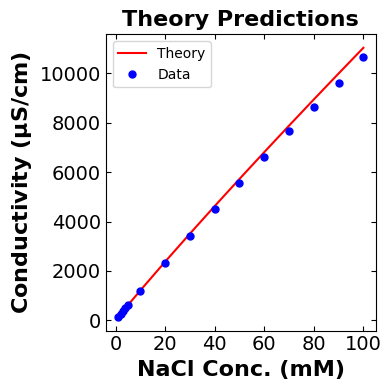

In [12]:
# making plot comparison of data and calculated values
fig = plt.figure(figsize=(4,4))
plt.plot(salt_conc, all_cond_calc_con, "r-", label="Theory")
plt.plot(salt_conc, cond_exp, "b.", markersize=10, label="Data")
plt.xlabel("NaCl Conc. (mM)", fontsize=16,fontweight='bold')
plt.ylabel("Conductivity ($\mathbf{\mu}$S/cm)", fontsize=16,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.title("Theory Predictions", fontsize=16,fontweight='bold')
plt.legend()
plt.tight_layout()
# plt.savefig("msc_model_na.png")
plt.show()

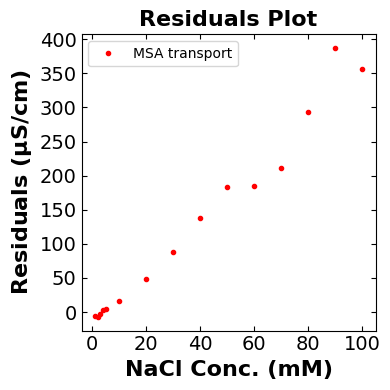

In [13]:
# residuals
residuals_Na = [all_cond_calc_con[i] - cond_exp[i] for i in range(ndata)]

# making plot of residuals of calculated specific conductivity
fig = plt.figure(figsize=(4,4))
plt.plot(salt_conc, residuals_Na, "r.", label="MSA transport")
plt.title("Residuals Plot", fontsize=16,fontweight='bold')
plt.xlabel("NaCl Conc. (mM)", fontsize=16,fontweight='bold')
plt.ylabel("Residuals ($\mathbf{\mu}$S/cm)", fontsize=16,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.legend()
plt.tight_layout()
plt.show()